In [1]:
!pip install -q ucimlrepo

import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from numpy.linalg import svd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Fetch the dataset (ID 350 = Default of Credit Card Clients)
print("Fetching dataset from UCI Repository...")
taiwan_credit = fetch_ucirepo(id=350)
X_raw = taiwan_credit.data.features
y_raw = taiwan_credit.data.targets

# Combine into a single dataframe for processing
df = pd.concat([X_raw, y_raw], axis=1)
target_col = y_raw.columns[0]
feature_names = X_raw.columns.tolist()

print(f"Dataset Loaded: {df.shape[0]} rows, {len(feature_names)} features.")

Fetching dataset from UCI Repository...
Dataset Loaded: 30000 rows, 23 features.


In [2]:
# 1. Balance the dataset (Undersampling)
df_default = df[df[target_col] == 1]
df_no_default = df[df[target_col] == 0].sample(len(df_default), random_state=42)
df_balanced = pd.concat([df_default, df_no_default]).sample(frac=1, random_state=42)

# 2. Normalize features to [0, 1]
scaler = MinMaxScaler()
df_balanced[feature_names] = scaler.fit_transform(df_balanced[feature_names])

# 3. Define bounds for the attack (physical limits of the data)
bounds = [df_balanced[feature_names].min().values, df_balanced[feature_names].max().values]

print(f"Balanced Dataset Size: {len(df_balanced)} samples.")

Balanced Dataset Size: 13272 samples.


In [3]:
def clip(current, low_bound, up_bound):
    return torch.max(torch.min(current, torch.FloatTensor(up_bound)), torch.FloatTensor(low_bound))

def deepfool(x_old, net, maxiters, alpha, bounds, overshoot=0.02):
    x = Variable(x_old.clone(), requires_grad=True)
    output = net.forward(x)
    orig_pred = output.max(0, keepdim=True)[1]

    # Target index for binary classification
    I = [0, 1] if orig_pred.item() == 0 else [1, 0]
    r_tot = np.zeros(x_old.numpy().shape)
    k_i = orig_pred

    loop_i = 0
    while torch.eq(k_i, orig_pred) and loop_i < maxiters:
        # Calculate gradients for both classes
        output[I[0]].backward(retain_graph=True)
        grad_orig = x.grad.data.numpy().copy()
        net.zero_grad()

        output[I[1]].backward(retain_graph=True)
        cur_grad = x.grad.data.numpy().copy()
        net.zero_grad()

        # DeepFool optimization step
        w = cur_grad - grad_orig
        f = (output[I[1]] - output[I[0]]).data.numpy()
        pert = abs(f) / (np.linalg.norm(w.flatten())**2 + 1e-8)

        r_tot += (pert * w) * alpha
        pert_x = x_old + (1 + overshoot) * torch.from_numpy(r_tot).float()
        pert_x = clip(pert_x, bounds[0], bounds[1])

        x = Variable(pert_x, requires_grad=True)
        output = net.forward(x)
        k_i = torch.tensor(np.argmax(output.data.cpu().numpy().flatten()))
        loop_i += 1

    return orig_pred.item(), k_i.item(), pert_x.detach().cpu().numpy()

In [4]:
class TaiwanNet(nn.Module):
    def __init__(self, D_in):
        super(TaiwanNet, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=0)
        )
    def forward(self, x): return self.layer(x)

X_tensor = torch.FloatTensor(df_balanced[feature_names].values)
y_tensor = torch.nn.functional.one_hot(torch.LongTensor(df_balanced[target_col].values)).float()
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

model = TaiwanNet(len(feature_names))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

print("Training model...")
for epoch in range(100):
    optimizer.zero_grad()
    loss = criterion(model(X_train), y_train)
    loss.backward()
    optimizer.step()
print("Model Training Complete.")

Training model...
Model Training Complete.


In [6]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from numpy.linalg import svd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo


# Systematic SVD and t-SNE Data Collection ---
alphas = [0.01, 0.1, 0.5, 1.0]
results = []
# We attack a subset of samples for better visualization speed
test_samples = X_test[:2000]

# 1. Get SVD of Original Data
U_orig, s_orig, Vh_orig = svd(test_samples.numpy(), full_matrices=False)
svd_spectrums = {0: s_orig} # Store original spectrum
tsne_data = [pd.DataFrame(test_samples.numpy(), columns=feature_names).assign(Type='Original')]

print("Analyzing DeepFool spectrums and manifolds...")
for a in alphas:
    adv_batch = []
    fooled = 0
    for x in tqdm(test_samples, desc=f"Alpha={a}"):
        orig, adv, x_adv = deepfool(x, model, 50, a, bounds, overshoot=0.02)
        adv_batch.append(x_adv)
        if orig != adv: fooled += 1

    # 2. Store SVD Spectrum for this Alpha
    adv_matrix = np.array(adv_batch)
    _, s_adv, _ = svd(adv_matrix, full_matrices=False)
    svd_spectrums[a] = s_adv

    # 3. Store Data for t-SNE
    tsne_data.append(pd.DataFrame(adv_matrix, columns=feature_names).assign(Type=f'Alpha={a}'))

    svd_damage = np.linalg.norm(s_orig - s_adv)
    results.append({'alpha': a, 'success': fooled/len(test_samples), 'svd': svd_damage})

res_df = pd.DataFrame(results)

Analyzing DeepFool spectrums and manifolds...


Alpha=1.0: 100%|██████████| 200/200 [00:00<00:00, 547.29it/s]


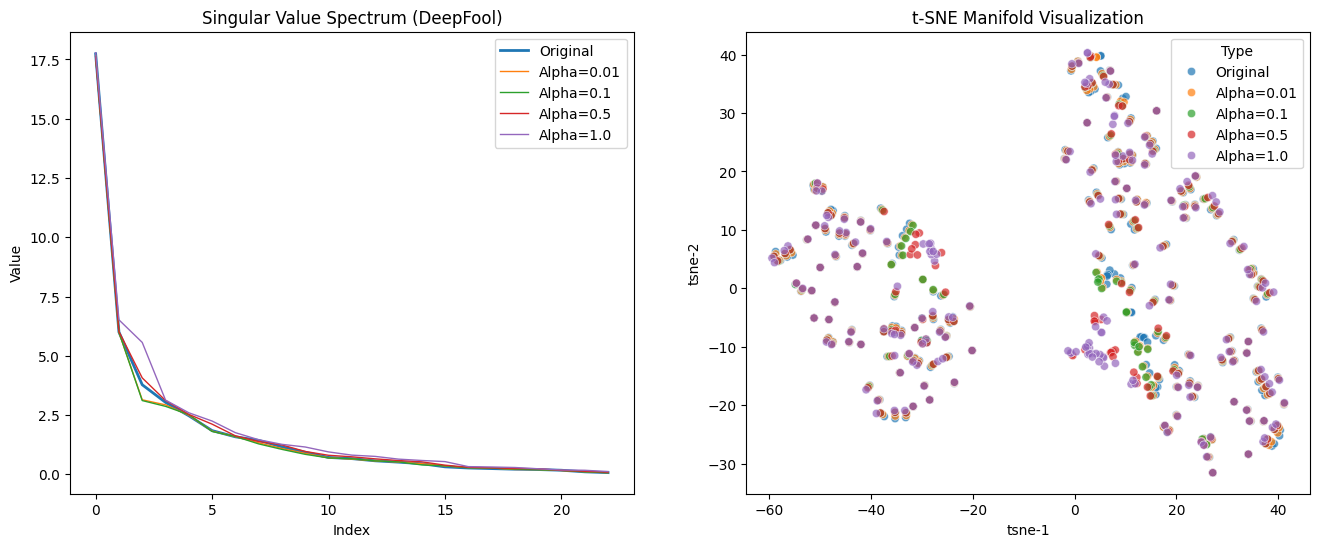

In [8]:
# --- SVD Spectrum and t-SNE Plotting ---
from sklearn.manifold import TSNE

plt.figure(figsize=(16, 6))

# Plot 1: SVD Spectrum
plt.subplot(1, 2, 1)
for a, s in svd_spectrums.items():
    label = "Original" if a == 0 else f"Alpha={a}"
    plt.plot(s, label=label, linewidth=2 if a==0 else 1)
plt.title("Singular Value Spectrum (DeepFool)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()

# Plot 2: t-SNE Manifold
plt.subplot(1, 2, 2)
combined_df = pd.concat(tsne_data)
tsne_res = TSNE(n_components=2, random_state=42).fit_transform(combined_df.drop('Type', axis=1))
combined_df['tsne-1'] = tsne_res[:, 0]
combined_df['tsne-2'] = tsne_res[:, 1]
sns.scatterplot(data=combined_df, x='tsne-1', y='tsne-2', hue='Type', alpha=0.7)
plt.title("t-SNE Manifold Visualization")
plt.show()